## **Exploratory Data Analysis of an Image Dataset**

#### **Dataset Contents**

The dataset itself was constructed using the following datasets:
* [Nature Dataset](https://huggingface.co/datasets/mertcobanov/nature-dataset) - Nature photos 
* [European Cities 1M dataset](http://image.ntua.gr/iva/datasets/ec1m/index.html) - Town pictures
* [CelebA Dataset](https://www.kaggle.com/datasets/jessicali9530/celeba-dataset) - People' faces

#### **The Process of Data Collection**

* The [Nature Dataset](https://huggingface.co/datasets/mertcobanov/nature-dataset) was fully included ($50.000$ images).

* We downloaded $50.000$ images at random by accessing the provided links [European Cities 1M dataset](http://image.ntua.gr/iva/datasets/ec1m/index.html). There exists [European Cities 50K dataset](http://image.ntua.gr/iva/datasets/ec50k/index.html) version. However, some links were not achievable, thus we used its bigger version.

* [CelebA Dataset](https://www.kaggle.com/datasets/jessicali9530/celeba-dataset) — $50.000$ images were randomly sampled.

#### **Dataset Format**

The $150.000$ images (`.jpg` format) are located in the *images* folder, the csv file contains `filename` and `category` columns. There are $3$ categories: `nature`, `city`, `faces`.

In [190]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import hashlib
import os
from collections import defaultdict

image_dir = 'dataset/images'

sns.set_palette(sns.color_palette('Set2'))

In [191]:
df = pd.read_csv('dataset/dataset.csv')
df.head()

,filename,category
0,000001.jpg,faces
1,000002.jpg,faces
2,000003.jpg,faces
3,000004.jpg,faces
4,000005.jpg,faces


In [192]:
df['index'] = df.groupby('category').cumcount()
pivot_df = df.pivot(index='index', columns='category', values='filename')

pivot_df.columns.name = None
pivot_df.reset_index(drop=True, inplace=True)
df = df.drop(columns=['index'], axis=1)

pivot_df

,city,faces,nature
0,050001.jpg,000001.jpg,100001.jpg
1,050002.jpg,000002.jpg,100002.jpg
2,050003.jpg,000003.jpg,100003.jpg
3,050004.jpg,000004.jpg,100004.jpg
4,050005.jpg,000005.jpg,100005.jpg
...,...,...,...
49995,099996.jpg,049996.jpg,149996.jpg
49996,099997.jpg,049997.jpg,149997.jpg
49997,099998.jpg,049998.jpg,149998.jpg
49998,099999.jpg,049999.jpg,149999.jpg


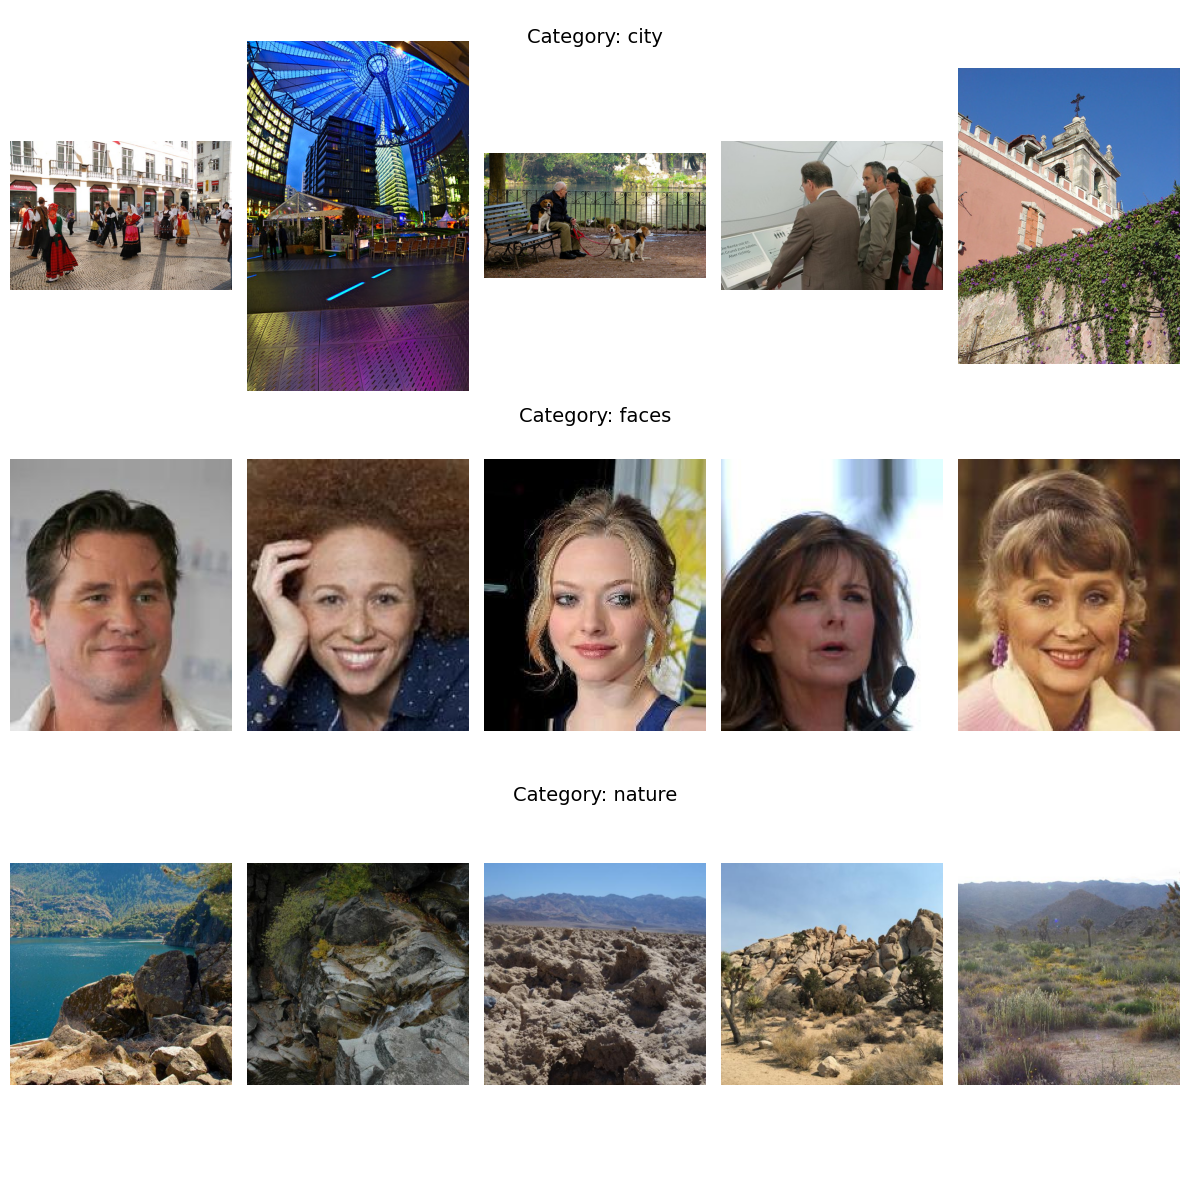

In [203]:
image_dir = 'dataset/images'
categories = ['city', 'faces', 'nature']

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 12))

for ax_index, category in enumerate(categories):
    selected_files = np.random.choice(pivot_df[category].dropna().tolist(), size=5, replace=False)
    
    for index, file in enumerate(selected_files):
        img = plt.imread(f'{image_dir}/{file}')
        
        sub_ax = fig.add_subplot(len(categories), 5, 
                                ax_index * 5 + index + 1)
        
        sub_ax.imshow(img)
        sub_ax.axis('off')

    axes[ax_index].axis('off')
    axes[ax_index].set_title(f'Category: {category}', fontsize=14, y=0.9)

plt.tight_layout()
plt.show()

In [204]:
df.category.value_counts().reset_index()

,category,count
0,faces,50000
1,city,50000
2,nature,50000


In [205]:
hash_groups = defaultdict(list)

for idx, row in df.iterrows():
    img_path = os.path.join(image_dir, row['filename'])
    
    with open(img_path, 'rb') as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
    
    hash_groups[file_hash].append({
        'filename': row['filename'],
        'category': row['category']
    })
        

duplicates = {hash_val: group for hash_val, group in hash_groups.items() if len(group) > 1}

In [206]:
categories = set()
amount = 0
for hash_val, group in duplicates.items():
    for dup in group:
        categories.add(dup['category'])
    amount += len(group) - 1

print(f'Duplicates amount: {amount}')
print(f'Categories:  {categories}')

Duplicates amount: 56
Categories:  {'faces', 'nature'}


In [207]:
to_remove = []
for hash_val, group in duplicates.items():
    group.pop()
    filenames = [item['filename'] for item in group]
    to_remove.extend(filenames)

df = df[~df['filename'].isin(to_remove)].reset_index(drop=True)

In [208]:
df.category.value_counts().reset_index()

,category,count
0,city,50000
1,faces,49996
2,nature,49948


In [209]:
def get_resolution(filename: str):
    img = Image.open(f'{image_dir}/{filename}')
    return img.width, img.height

res = df['filename'].apply(lambda filename: get_resolution(filename))
df['width'] = res.apply(lambda x: x[0])
df['height'] = res.apply(lambda x: x[1])

df

,filename,category,width,height
0,000001.jpg,faces,178,218
1,000002.jpg,faces,178,218
2,000003.jpg,faces,178,218
3,000004.jpg,faces,178,218
4,000005.jpg,faces,178,218
...,...,...,...,...
149939,149996.jpg,nature,512,512
149940,149997.jpg,nature,512,512
149941,149998.jpg,nature,512,512
149942,149999.jpg,nature,512,512


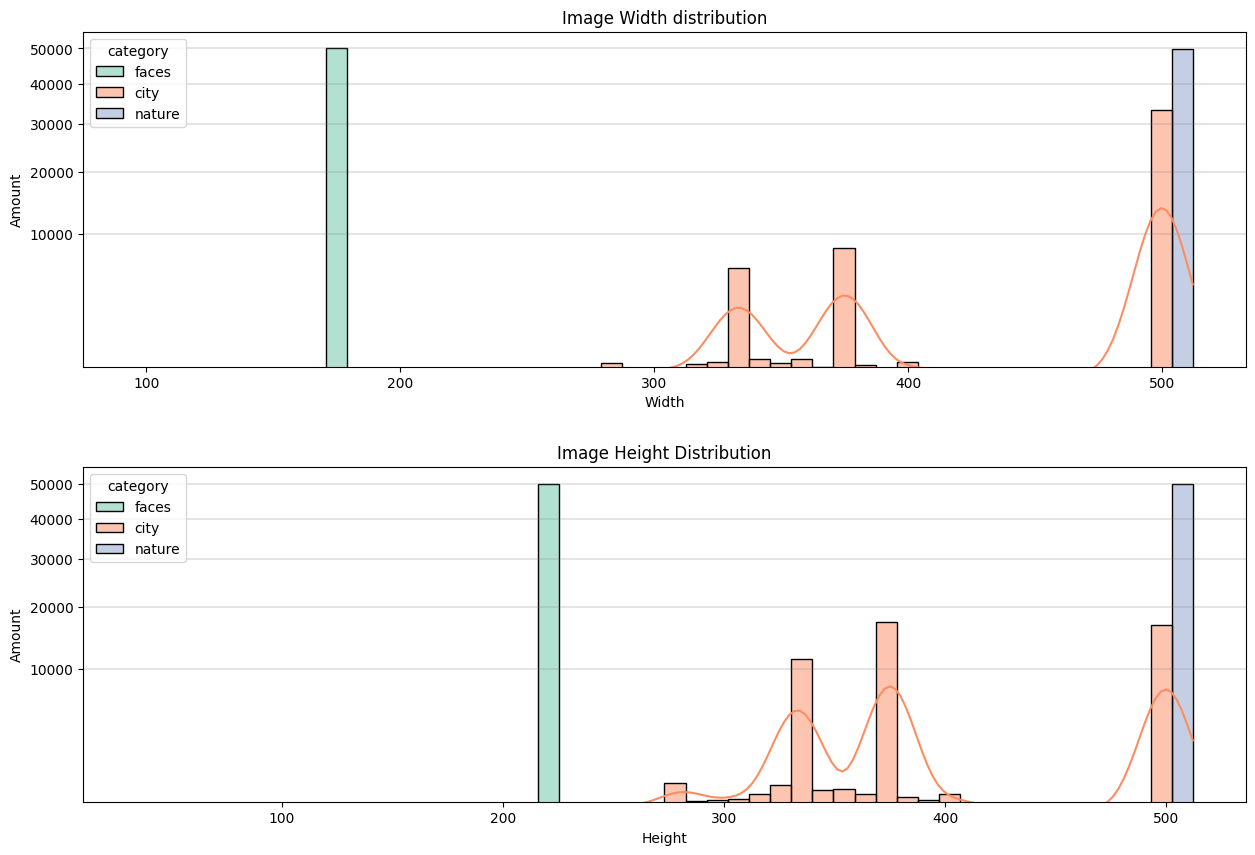

In [210]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# set scale
axes[0].set_yscale('function', functions=(np.sqrt, np.square))
axes[1].set_yscale('function', functions=(np.sqrt, np.square))


# turn on the grid
axes[0].grid(axis='y', color='grey', linewidth=0.3)
axes[1].grid(axis='y', color='grey', linewidth=0.3)


# draw plots
sns.histplot(data=df, x='width', hue='category', bins=50, kde=True, ax=axes[0])
sns.histplot(data=df, x='height', hue='category', bins=50, kde=True, ax=axes[1])


# set titles
axes[0].set_title('Image Width distribution')
axes[0].set_xlabel('Width')
axes[0].set_ylabel('Amount')

axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height')
axes[1].set_ylabel('Amount')


fig.subplots_adjust(hspace=0.3)

plt.show()


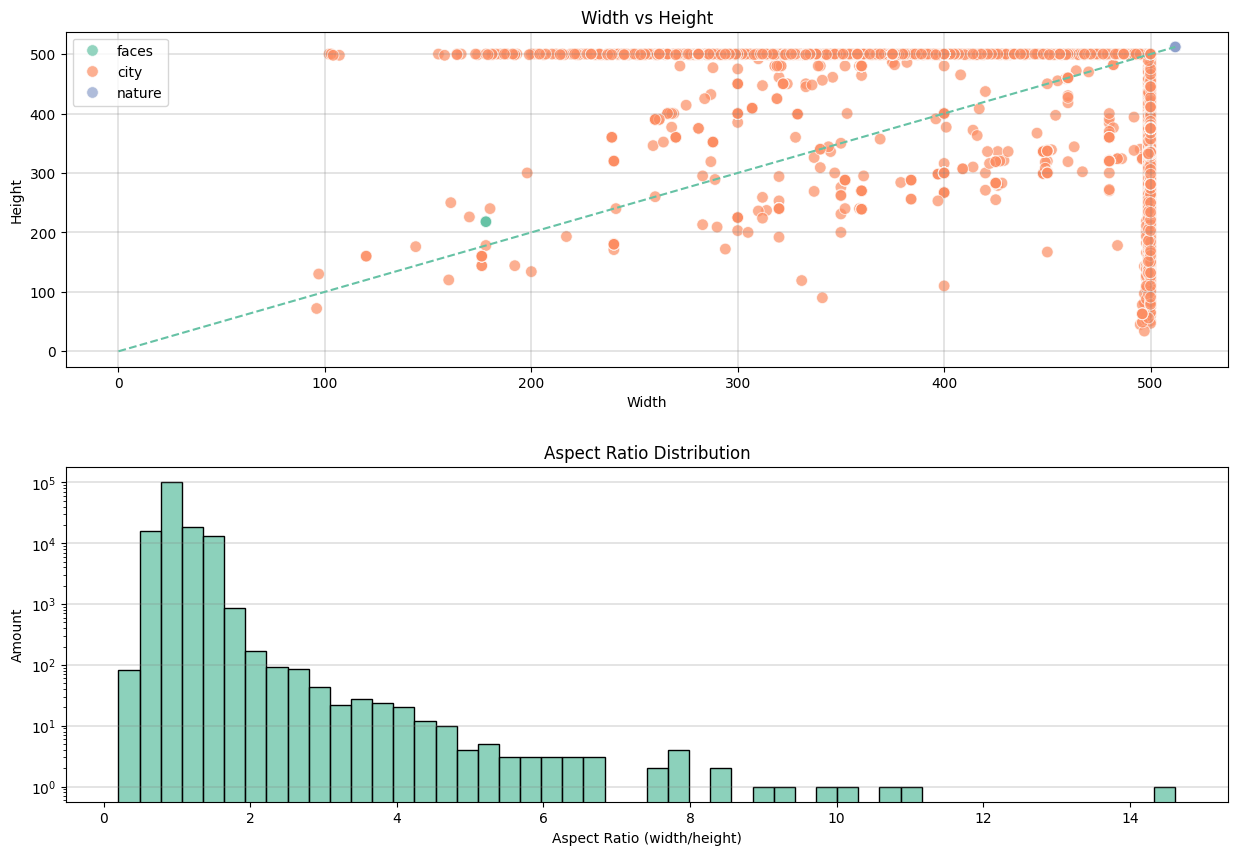

In [212]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
df['aspect_ratio'] = df['width'] / df['height']

# set scale
axes[1].set_yscale('log')


# turn on the grid
axes[0].grid(color='grey', linewidth=0.3)
axes[1].grid(axis='y', color='grey', linewidth=0.3)


# draw plots
sns.scatterplot(data=df, x='width', y='height', s=70, alpha=0.7, hue='category', ax=axes[0])

sns.histplot(data=df, x='aspect_ratio', bins=50, kde=False, ax=axes[1])
sns.lineplot(x=[0, df['width'].max()], y=[0, df['height'].max()], ax=axes[0], linestyle='--')


# set titles
axes[0].set_title('Width vs Height')
axes[0].set_xlabel('Width')
axes[0].set_ylabel('Height')

axes[1].set_title('Aspect Ratio Distribution')
axes[1].set_xlabel('Aspect Ratio (width/height)')
axes[1].set_ylabel('Amount')


fig.subplots_adjust(hspace=0.3)

plt.show()